Tên: Lê Văn Huy | MSSV: 070206007733

In [ ]:
import matplotlib.pyplot as plt #thư viện này để vẽ đồ thị
import numpy as np #để tính toán ma trận
from matplotlib.colors import ListedColormap #có thể chọn màu cho hình vẽ
from sklearn.datasets import make_circles, make_classification, make_moons 
#sinh dữ liệu trong đó circles để xếp thành 2 vòng tròn lồng nhau,
#classification tạo dữ liệu ngẫu nhiên, có thể phân chia và make_moons tạo các điểm 
#xếp thành 2 hình trăng khuyết đan vào nhau
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay #vẽ ranh giới giữa các hình
from sklearn.model_selection import train_test_split #chia dữ liệu để học, test
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline #gom nhiều bước xử lý thành 1 dãy tự động
from sklearn.preprocessing import StandardScaler #chuẩn hóa dữ liệu trước khi đưa vào học
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
#còn lại là moi ra 10 thuật toán phân loại từ thư viện để chuẩn bị so coi thuật toán nào là tốt nhất

In [ ]:
names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
] #tên mô hình in lên mỗi đầu cột đồ thị

classifiers = [
    KNeighborsClassifier(3), #nhìn vào 3 hàng xóm gần nhất sau đó đoán thuộc tính của mình
    SVC(kernel="linear", C=0.025, random_state=42), #kẻ 1 đường thẳng để chia dữ liệu, cố định random_state = 42 
                                                    #(cố định bộ sinh số ngẫu nhiên) cho tất cả để có tính nhất quán
    SVC(gamma=2, C=1, random_state=42), #dùng đường con để bọc lại dữ liệu
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42), #dùng xác suất để phân phối
    DecisionTreeClassifier(max_depth=5, random_state=42), #sử dụng cây quyết định tối đa 5 câu hỏi để rẽ nhanhs
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42 #ghép 10 cây quyết định lại để để ra quyết định cuối
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42), #1000 vòng lặp mạng nơ ron
    AdaBoostClassifier(random_state=42),#cho các mô hình học nhau, mô hình sau sửa sai cho mô hình trước
    GaussianNB(), #naive bayes
    QuadraticDiscriminantAnalysis(), #phân chia đường cong bậc 2
]

In [ ]:
X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
      #tạo ra tập duex liệu gồm x tọa độ trên mặt phẳng 2d và y, mỗi nhóm thành 1 cụm
)
rng = np.random.RandomState(2)#sinh số ngẫu nhiên phục vụ cho bên dưới cộng thêm vào x
X += 2 * rng.uniform(size=X.shape)#cộng ttheem vào x với mục đích cho các điểm dạt ra một chút
linearly_separable = (X, y) #đặt tên cho bộ này là linearly_separable

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
] #gom cả 3 dạng để bài vào 1 danh sách

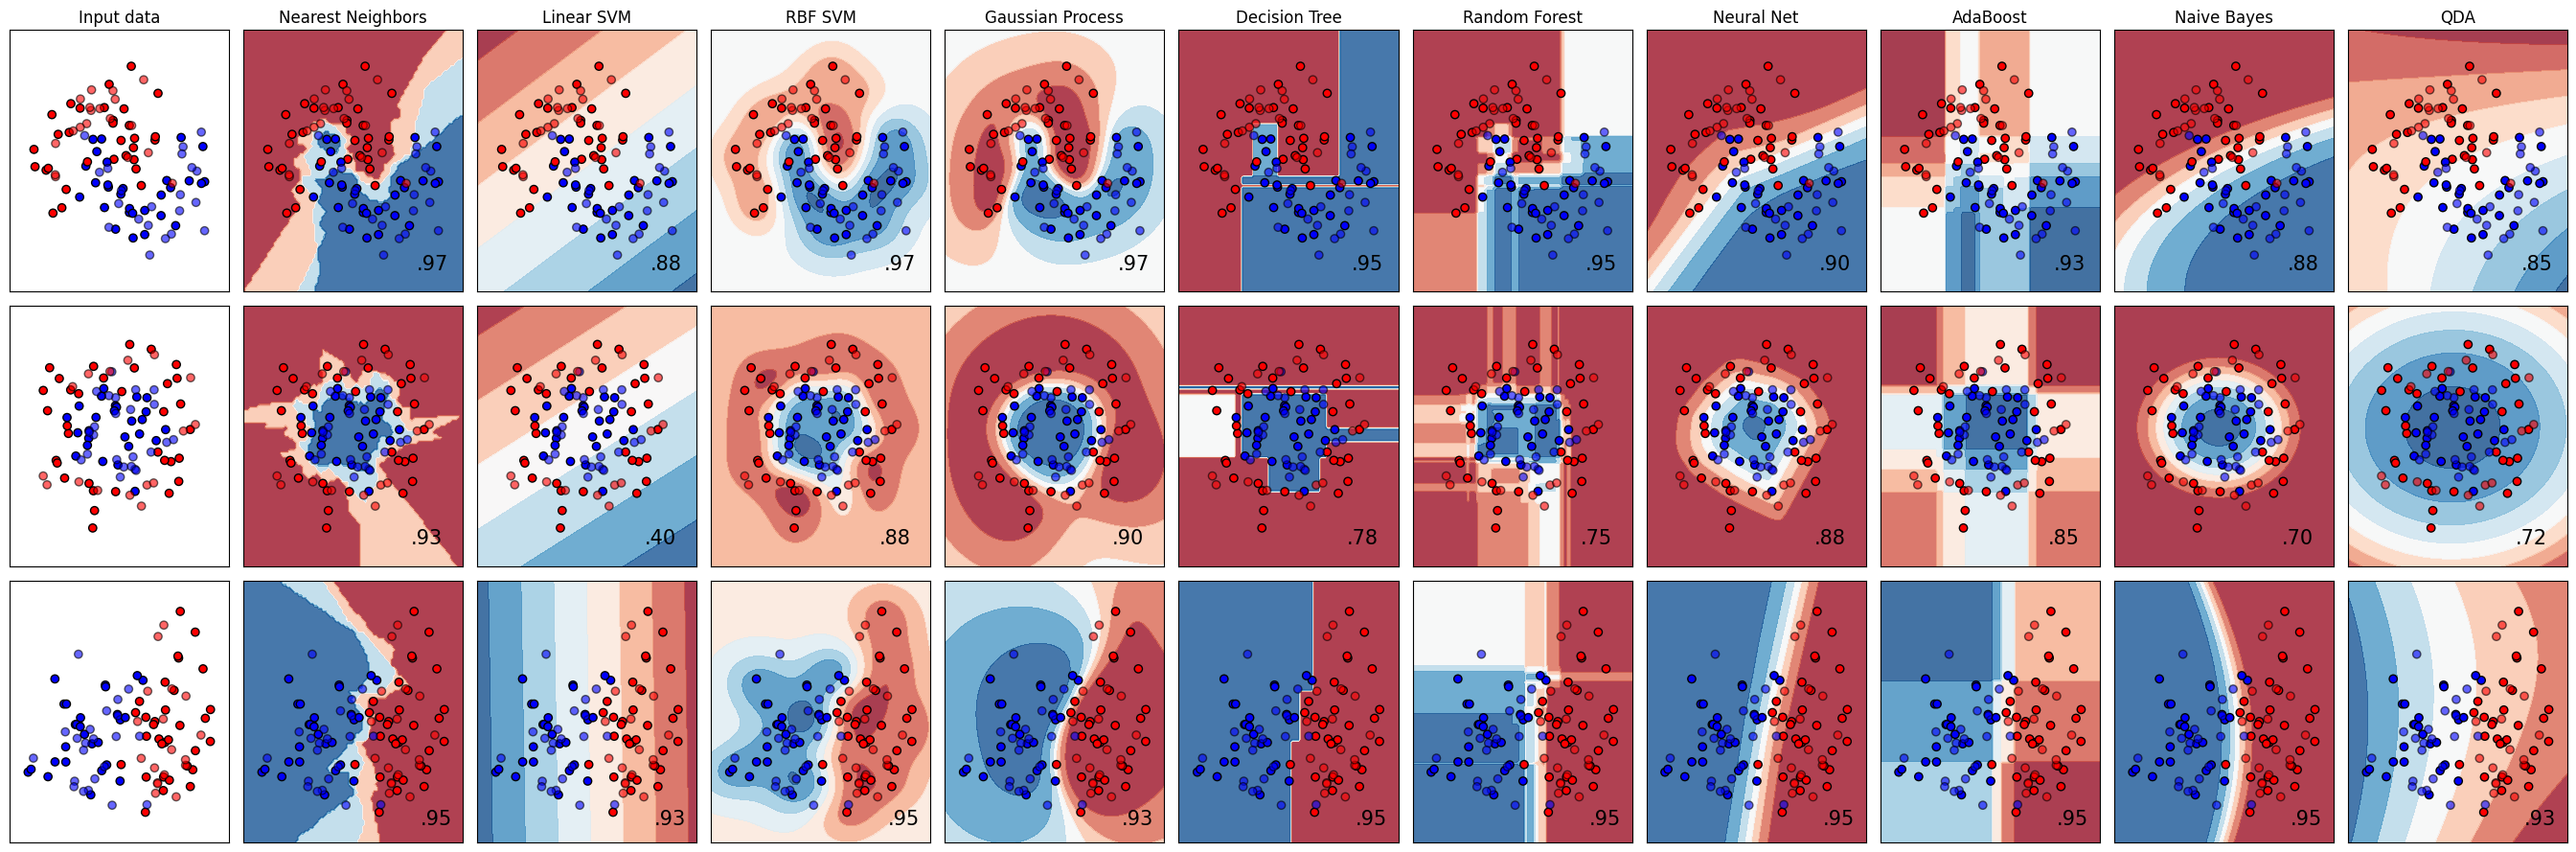

In [ ]:
figure = plt.figure(figsize=(27, 9)) #vẽ theo kích thước rộng 27in, cao 9in
i = 1 #biến đêm bắt đầu để đánh số vị trí các ô vẽ subplot từ trái qua phải, trên xuống dưới
for ds_cnt, ds in enumerate(datasets):#bắt đầu duyệt qua từng bộ dữ liệu của datasets
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
        #lấy ra tọa độ x và nhãn y, cho máy học 60% và 40% để test
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 #tìm x, y nhỏ nhất và lớn nhất rồi cộng thêm 0.5 để biểu đồ kh bị sát viền
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    cm = plt.cm.RdBu #dải màu tô nền ranh giới
    cm_bright = ListedColormap(["#FF0000", "#0000FF"]) #chọn 2 màu tương phản tốt để chấm điểm dữ liệu
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i) #3hangf và 11 cột
    if ds_cnt == 0:
        ax.set_title("Input data") #nếu đang ở hàng đầu tiên thì gắn chuỗi input data
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
        #ax.scatter để chấm điểm dữ liệu lên ô vẽ, điểm train thì vẽ màu đậm, viền đen còn test thì hơi mờ 
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1
    #khóa giới hạn x y, ẩn các con số trên 2 trục tọa độ, tăng i để chuyển qua ô tiếp theo
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i) #mở 1 ô vẽ mới với name tương ứng với clf

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        #Bắt buộc dữ liệu đi qua để chuẩn hóa bằng StandardScaler, sau đó dùng lệnh fit để bắt đầu train
        score = clf.score(X_test, y_test) #test thử mô hình để tính tỉ lệ chính xác
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
            #vẽ màu nền phân cách, đoán là nhóm 0 thì tô đỏ, nhóm 1 thì tô xanh
        )
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )
        #chấm màu dữ liệu lên cái vừa vẽ để thấy được mô hình phân loại đúng hay sai
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        #cố định khung và ẩn các vạch chia
        if ds_cnt == 0:
            ax.set_title(name) #nếu đang ở hàng đầu tiên thì in tên thuật toán
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1
        #ax.text(...) i+= 1 là để in thông số điểm chính xác vào góc, tăng i cho chuẩn bị cho ô tiếp theo

plt.tight_layout() #tự động căn chỉnh khoảng cách
plt.show() #xuất hình